# <center> ISEL - AA </center>
## <center>Semestre 2025/26 </center>
###  <center> Trabalho 2 - Classificação de Críticas de Cinema do IMDb</center>

Trabalho realizado por:
* Lucas Duarte, número <b> 50735 </b>
* Rafael Dias, número <b> 50773 </b>
* Miguel Sedas, número <b> 50801  </b>

<b> Turma 52D </b> <br></br>
<b> Docente: Gonçalo Xufre </b>

# Introdução

Escrever introdução

## Imports

In [2]:
import pandas as pd
import pickle
import re
from pydoc import doc
from typing import Counter

import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    ConfusionMatrixDisplay
)
from sklearn.svm import LinearSVC
from nltk.stem import SnowballStemmer


## Carregamento de dados

In [3]:
with open("imdbFull.p", "rb") as data_file: 
    D = pickle.load(data_file)
    
print(D.keys(), "\n")
print(D.DESCR)

dict_keys(['data', 'target', 'DESCR']) 

This dataset contains movie reviews along with their associated binary sentiment polarity labels. It is intended to serve as a benchmark for sentiment classification. This document outlines how the dataset was gathered, and how to use the files provided.
For more details see: http://ai.stanford.edu/~amaas/data/sentiment/


50000
[ 1  2  3  4  7  8  9 10]


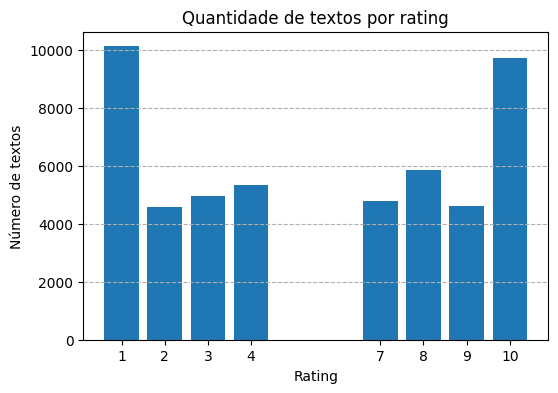

In [4]:
# Extrair dados
Docs = D["data"]
y = D["target"]

print(len(y))
print(np.unique(y))

# Contar textos por rating
unique, counts = np.unique(y, return_counts=True)

# Gráfico
plt.figure(figsize=(6, 4))
plt.bar(unique, counts)
plt.xlabel("Rating")
plt.ylabel("Número de textos")
plt.title("Quantidade de textos por rating")
plt.xticks(unique)
plt.grid(axis='y', linestyle='--')
plt.show()

Como é possível observar acima, verifica-se que o dataset tem as classes representantes das notas "5" e "6" eliminadas. O gráfico acima criado ajuda oferece uma forma mais visual de como estão distribuidas o número de críticas por "rating".

# Construção do Vocabulário

## Divisão dos dados em subconjuntos

No trabalho anterior (TP1) foi realizada uma divisão dos dados em três subconjuntos distintos — treino, validação e teste — de forma a garantir uma avaliação rigorosa e imparcial dos modelos. No presente trabalho seguiu-se exatamente a mesma metodologia, repetindo a divisão tripartida dos dados por consistência experimental e para assegurar a comparabilidade entre abordagens.

A divisão utilizada foi a seguinte: 50% dos dados para treino, 30% para validação e 20% para teste. Esta distribuição permite um equilíbrio adequado entre os diferentes objetivos da modelação.
O conjunto de treino (50%) fornece uma quantidade suficiente de exemplos para aprender os padrões relevantes presentes nas críticas de cinema. O conjunto de validação (30%) é utilizado durante o desenvolvimento para testar combinações de hiperparâmetros, escolher o melhor vocabulário TF-IDF e selecionar os modelos mais eficazes sem recorrer aos dados de teste. Por fim, o conjunto de teste (20%) é completamente isolado até ao final do trabalho e serve para obter uma estimativa imparcial do desempenho real dos modelos perante dados nunca antes observados.

In [5]:
# Proporções de cada conjunto
treino_ratio = 0.5
valid_ratio = 0.3

# Tamanhos para cada conjunto
treino_size = int(len(Docs) * treino_ratio)
valid_size = int(len(Docs) * valid_ratio)

# Dividir X e y entre treino, validação e teste
X_train = Docs[:treino_size]
y_train = y[:treino_size]

X_valid = Docs[treino_size:treino_size + valid_size]
y_valid = y[treino_size:treino_size + valid_size]

X_test = Docs[treino_size + valid_size:]
y_test = y[treino_size + valid_size:]

# Print dos tamanhos de cada conjunto
print("Conjunto de treino:", len(X_train), len(y_train))
print("Conjunto de validação:", len(X_valid), len(y_valid))
print("Conjunto de teste:", len(X_test), len(y_test))

Conjunto de treino: 25000 25000
Conjunto de validação: 15000 15000
Conjunto de teste: 10000 10000


## Limpeza do Texto e Stemning

A limpeza do texto é uma etapa fundamental, sobretudo quando se trabalha com modelos que dependem diretamente da qualidade das representações textuais, como o TF-IDF. Os textos originais, especialmente em bases de dados reais como o IMDb, contêm elementos que não contribuem para o significado — tags HTML, pontuação desnecessária, letras maiúsculas misturadas, múltiplos espaços ou símbolos que apenas aumentam o ruído. Se estes elementos forem mantidos, acabam por inflacionar artificialmente o vocabulário, criando milhares de "palavras" diferentes que o modelo interpreta como termos relevantes, mas que não têm qualquer utilidade semântica. Uma boa limpeza reduz este ruído, normaliza o texto e garante que palavras que representam a mesma ideia tenham exatamente a mesma forma.

Outro componente crucial do pré-processamento é o stemming. O stemming consiste em reduzir cada palavra à sua raiz ou forma base, cortando prefixos ou sufixos. Por exemplo, palavras como loved, loving e loves tornam-se love. Esta normalização traz duas vantagens importantes: diminui ainda mais o tamanho do vocabulário e aumenta a densidade da informação, porque várias formas flexionadas passam a ser tratadas como a mesma palavra. Isto permite ao modelo capturar melhor os padrões subjacentes ao sentimento das críticas, em vez de desperdiçar capacidade a distinguir variações irrelevantes de uma mesma palavra. Embora seja um processo agressivo que pode gerar formas artificiais, na prática costuma melhorar o desempenho de classificadores e regressões baseadas em TF-IDF, especialmente em conjuntos de dados grandes como este.

Assim, tanto a limpeza de texto quanto o stemming são etapas essenciais para garantir um vocabulário mais compacto, consistente e sem ruído, permitindo que os modelos foquem nos padrões realmente informativos presentes nas críticas.

In [6]:
# Limpeza do texto

def clean_text(doc):
    # 1. Remover quebras HTML específicas do IMDb
    doc = doc.replace('<br />', ' ')

    # 2. Lowercase (importante antes de regex e stemming)
    doc = doc.lower()

    # 3. Remover tudo o que não seja letras (inclui acentos)
    doc = re.sub(r'[^a-zA-Z\u00C0-\u00FF]+', ' ', doc)

    # 4. Remover espaços múltiplos
    doc = re.sub(r'\s+', ' ', doc).strip()

    return doc

Docs_clean = [clean_text(doc) for doc in Docs]

print("Exemplo antes:")
print(Docs[0][:300])

print("\nExemplo depois da limpeza:")
print(Docs_clean[0][:300])


# Stemning

stemmer = SnowballStemmer("english")

def stem_text(doc):
    return ' '.join(stemmer.stem(w) for w in doc.split())

Docs_stemmed = [stem_text(doc) for doc in Docs_clean]

print("\nExemplo após stemming:")
print(Docs_stemmed[0][:300])

Exemplo antes:
Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mu

Exemplo depois da limpeza:
zero day leads you to think even re think why two boys young men would do what they did commit mutual suicide via slaughtering their classmates it captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own mutual

Exemplo após stemming:
zero day lead you to think even re think whi two boy young men would do what they did commit mutual suicid via slaughter their classmat it captur what must be beyond a bizarr mode of be for two human who have decid to withdraw from common civil in order to defin their own mutual world via coupl dest


## TF-IDF

A representação TF-IDF (Term Frequency–Inverse Document Frequency) é uma das abordagens mais utilizadas para transformar texto em informação numérica, sendo especialmente eficaz em tarefas de classificação de documentos. O seu objetivo é atribuir maior peso às palavras que são relevantes para distinguir documentos, reduzindo a importância de termos demasiado comuns e aumentando o peso de palavras informativas. Desta forma, o TF-IDF cria uma matriz esparsa que captura de forma eficiente o conteúdo semântico das críticas, permitindo que os modelos de aprendizagem automática identifiquem padrões associados às diferentes pontuações do IMDb.

A escolha dos parâmetros utilizados no TfidfVectorizer foi fundamentada em considerações experimentais e teóricas. O parâmetro token_pattern = r'\b\w\w+\b' garante que apenas palavras com dois ou mais caracteres são incluídas no vocabulário, removendo tokens pouco informativos como letras isoladas ou ruído residual da limpeza do texto. O valor min_df=3 permite excluir termos demasiado raros, que tendem a introduzir ruído e aumentar desnecessariamente a dimensionalidade sem acrescentar valor ao modelo. Da mesma forma, max_df=0.20 elimina palavras extremamente frequentes que aparecem em muitos documentos e que, por isso, não contribuem para distinguir diferentes classes de pontuação.

Para controlar a complexidade do vocabulário e manter um compromisso adequado entre desempenho e custo computacional, definiu-se max_features=24000, garantindo que apenas os termos mais relevantes são mantidos. O uso de ngram_range=(1, 2) permite incluir unigrams e bigrams, capturando não só palavras individuais, mas também expressões importantes como "very good" ou "not bad", que transportam significado mais rico do que palavras isoladas. Além disso, a opção lowercase=True assegura consistência entre tokens, e a remoção de stopwords em inglês (stop_words="english") reduz a presença de palavras funcionais que não acrescentam valor discriminativo ao modelo.

No conjunto, estes parâmetros resultam num vocabulário equilibrado e informativo, capaz de representar as críticas de cinema de forma eficiente. A matriz TF-IDF obtida revelou-se adequada para treinar os classificadores utilizados nas secções seguintes, apresentando uma boa relação entre qualidade semântica e tempo de processamento.

In [7]:
token_pattern = r'\b\w\w+\b'

tfidf = TfidfVectorizer(
    min_df=3,            # ignora termos raros
    max_df=0.20,         # ignora termos demasiado comuns
    max_features=24000,  # tamanho máximo do vocabulário
    token_pattern=token_pattern,
    ngram_range=(1, 2),  # unigrams + bigrams
    lowercase=True,      # garantir consistência
)

# Treinar o vocabulário apenas no treino
tfidf.fit(X_train)

vocab = tfidf.get_feature_names_out()

print("Tamanho do vocabulário:", len(vocab), "\n")

print("Exemplos do vocabulário (posição 200 a 250):")
print(vocab[500:550], "\n")

X_train_tfidf = tfidf.transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)

print("Formato da matriz TF-IDF (train):", X_train_tfidf.shape)
print("Formato da matriz TF-IDF (valid):", X_valid_tfidf.shape)

Tamanho do vocabulário: 24000 

Exemplos do vocabulário (posição 200 a 250):
['affleck' 'afford' 'afford to' 'aforementioned' 'afraid' 'afraid of'
 'afraid to' 'africa' 'african' 'african american' 'after about'
 'after all' 'after an' 'after another' 'after being' 'after few'
 'after having' 'after he' 'after her' 'after his' 'after it'
 'after reading' 'after seeing' 'after she' 'after some' 'after that'
 'after the' 'after their' 'after they' 'after this' 'after viewing'
 'after watching' 'after while' 'after you' 'aftermath' 'afternoon'
 'afterward' 'afterwards' 'again' 'again after' 'again and' 'again as'
 'again br' 'again but' 'again for' 'again he' 'again if' 'again in'
 'again it' 'again on'] 

Formato da matriz TF-IDF (train): (25000, 24000)
Formato da matriz TF-IDF (valid): (15000, 24000)


# Classificação e Regressão

## Classificação

### Logistic Regression

O Logistic Regression foi um dos classificadores selecionados para este trabalho por ser um modelo particularmente eficaz em tarefas de classificação de texto representado através de TF-IDF. Trata-se de um algoritmo linear, altamente escalável e adequado a dados de elevada dimensão, como é o caso das críticas de cinema, cujo vocabulário pode facilmente atingir dezenas de milhares de termos.

Para além destas vantagens, foram ainda testadas múltiplas configurações do Logistic Regression, variando certos parâmetros. Após esta fase de experimentação, verificou-se que a configuração escolhida apresentava o melhor desempenho global, oferecendo um equilíbrio superior entre precisão, capacidade de generalização e tempo de treino.

In [8]:
"""
# Definição de parâmetros para teste
C_values = [0.1, 0.5, 1.0, 3.0, 5.0]
solvers = ["lbfgs", "saga"]
class_weights = [None, "balanced"]

resultados = []

# Testa a combinação dos parâmetros definidos
for C in C_values:
    for solver in solvers:
        for cw in class_weights:
            print(f"Treinando modelo com C={C}, solver={solver}, class_weight={cw}")

            clf = LogisticRegression(
                C=C,
                solver=solver,
                class_weight=cw,
                multi_class="ovr",
                max_iter=2000,
                n_jobs=-1
            )

            # Treinar
            clf.fit(X_train_tfidf, y_train)

            # Validar
            y_pred = clf.predict(X_valid_tfidf)
            acc = accuracy_score(y_valid, y_pred)

            resultados.append({
                "C": C,
                "solver": solver,
                "class_weight": cw,
                "accuracy_val": acc
            })

# Cria uma tabela com os valores obtidos, ordenados pela accuracy
df_res = pd.DataFrame(resultados)
df_res = df_res.sort_values(by="accuracy_val", ascending=False)

print("\nResultados ordenados por accuracy da validação:\n")
print(df_res)
"""

'\n# Definição de parâmetros para teste\nC_values = [0.1, 0.5, 1.0, 3.0, 5.0]\nsolvers = ["lbfgs", "saga"]\nclass_weights = [None, "balanced"]\n\nresultados = []\n\n# Testa a combinação dos parâmetros definidos\nfor C in C_values:\n    for solver in solvers:\n        for cw in class_weights:\n            print(f"Treinando modelo com C={C}, solver={solver}, class_weight={cw}")\n\n            clf = LogisticRegression(\n                C=C,\n                solver=solver,\n                class_weight=cw,\n                multi_class="ovr",\n                max_iter=2000,\n                n_jobs=-1\n            )\n\n            # Treinar\n            clf.fit(X_train_tfidf, y_train)\n\n            # Validar\n            y_pred = clf.predict(X_valid_tfidf)\n            acc = accuracy_score(y_valid, y_pred)\n\n            resultados.append({\n                "C": C,\n                "solver": solver,\n                "class_weight": cw,\n                "accuracy_val": acc\n            })\n\

In [16]:
# Define o modelo de Regressão Logística.
clf = LogisticRegression(C=1.0, solver="saga", class_weight=None)

# Treina o modelo usando os dados de treino (X_train1) e as respectivas classes (y_train).
clf.fit(X_train_tfidf, y_train)

# Avaliação no conjunto de validação
y_pred_lr = clf.predict(X_valid_tfidf)

print(classification_report(y_valid, y_pred_lr))

              precision    recall  f1-score   support

           1       0.53      0.84      0.65      3033
           2       0.21      0.05      0.08      1408
           3       0.30      0.13      0.18      1503
           4       0.34      0.34      0.34      1615
           7       0.33      0.24      0.28      1378
           8       0.28      0.25      0.27      1698
           9       0.20      0.04      0.06      1401
          10       0.49      0.79      0.61      2964

    accuracy                           0.43     15000
   macro avg       0.33      0.34      0.31     15000
weighted avg       0.37      0.43      0.38     15000



### SVM

O Support Vector Machine (SVM) foi igualmente selecionado como classificador para este trabalho devido à sua eficácia reconhecida em tarefas de classificação de texto, especialmente quando os dados são representados através de vetores TF-IDF. O SVM é particularmente adequado para lidar com dados de elevada dimensão, beneficiando da sua capacidade de maximizar margens de separação e de criar fronteiras de decisão robustas mesmo em espaços com milhares de características, como acontece no conjunto de críticas de cinema.

Tal como no caso do Logistic Regression, foram testadas diversas configurações do SVM, ajustando certos parâmetros. Este processo de experimentação permitiu identificar a combinação de parâmetros que apresentava o melhor desempenho global, garantindo uma classificação mais precisa e uma melhor capacidade de generalização sobre dados não observados.

In [10]:
"""
# Definição de parâmetros para teste
C_values = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]

resultados_svm = []

# Testa a combinação dos parâmetros definidos
for C in C_values:

    # -------- loss = hinge (dual tem de ser True)
    clf = LinearSVC(C=C, loss="hinge", dual=True, max_iter=5000)
    print(f"Treinando SVM com C={C}, loss='hinge', dual=True")

    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_valid_tfidf)
    acc = accuracy_score(y_valid, y_pred)

    resultados_svm.append({
        "C": C,
        "loss": "hinge",
        "dual": True,
        "accuracy_val": acc
    })

    # -------- loss = squared_hinge (dual pode ser True OU False)
    for dual in [True, False]:
        print(f"Treinando SVM com C={C}, loss='squared_hinge', dual={dual}")

        clf = LinearSVC(C=C, loss="squared_hinge", dual=dual, max_iter=5000)
        clf.fit(X_train_tfidf, y_train)
        y_pred = clf.predict(X_valid_tfidf)
        acc = accuracy_score(y_valid, y_pred)

        resultados_svm.append({
            "C": C,
            "loss": "squared_hinge",
            "dual": dual,
            "accuracy_val": acc
        })

# Cria uma tabela com os valores obtidos, ordenados pela accuracy
df_svm = pd.DataFrame(resultados_svm)
df_svm = df_svm.sort_values(by="accuracy_val", ascending=False)

print("\nResultados SVM ordenados por accuracy da validação:\n")
print(df_svm)
"""

'\n# Definição de parâmetros para teste\nC_values = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]\n\nresultados_svm = []\n\n# Testa a combinação dos parâmetros definidos\nfor C in C_values:\n\n    # -------- loss = hinge (dual tem de ser True)\n    clf = LinearSVC(C=C, loss="hinge", dual=True, max_iter=5000)\n    print(f"Treinando SVM com C={C}, loss=\'hinge\', dual=True")\n\n    clf.fit(X_train_tfidf, y_train)\n    y_pred = clf.predict(X_valid_tfidf)\n    acc = accuracy_score(y_valid, y_pred)\n\n    resultados_svm.append({\n        "C": C,\n        "loss": "hinge",\n        "dual": True,\n        "accuracy_val": acc\n    })\n\n    # -------- loss = squared_hinge (dual pode ser True OU False)\n    for dual in [True, False]:\n        print(f"Treinando SVM com C={C}, loss=\'squared_hinge\', dual={dual}")\n\n        clf = LinearSVC(C=C, loss="squared_hinge", dual=dual, max_iter=5000)\n        clf.fit(X_train_tfidf, y_train)\n        y_pred = clf.predict(X_valid_tfidf)\n        acc = accuracy_scor

In [11]:
# Define o modelo SVM com os parâmetros pretendidos
clf = LinearSVC(C=0.10, loss="squared_hinge", dual=False)

# Treina o modelo usando os dados de treino
clf.fit(X_train_tfidf, y_train)

# Avaliação no conjunto de validação
y_pred_svm = clf.predict(X_valid_tfidf)

print(classification_report(y_valid, y_pred_svm))

              precision    recall  f1-score   support

           1       0.50      0.88      0.64      3033
           2       0.20      0.04      0.06      1408
           3       0.29      0.09      0.14      1503
           4       0.35      0.32      0.33      1615
           7       0.35      0.24      0.28      1378
           8       0.28      0.21      0.24      1698
           9       0.20      0.03      0.05      1401
          10       0.47      0.82      0.60      2964

    accuracy                           0.43     15000
   macro avg       0.33      0.33      0.29     15000
weighted avg       0.36      0.43      0.36     15000



### Comparação entre os dois modelos de classificação

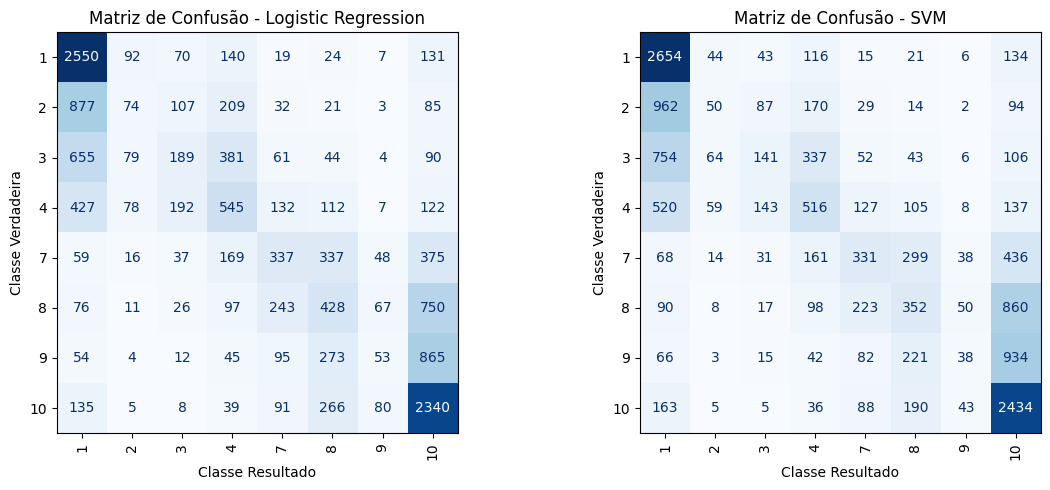

In [12]:
# Lista de previsões e nomes para cada modelo
predicoes = [("Logistic Regression", y_pred_lr), ("SVM", y_pred_svm)]

# Criar uma figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nome_modelo, y_pred) in zip(axes, predicoes):
    # Calcular a matriz de confusão usando y_valid
    conf_matrix = confusion_matrix(y_valid, y_pred)

    # Gerar a matriz de confusão no subplot correspondente
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y_valid))
    disp.plot(cmap="Blues", xticks_rotation="vertical", ax=ax, colorbar=False)

    # Configurações do subplot
    ax.set_title(f"Matriz de Confusão - {nome_modelo}")
    ax.set_xlabel("Classe Resultado")
    ax.set_ylabel("Classe Verdadeira")

# Ajustar layout para não sobrepor elementos
plt.tight_layout()
plt.show()

A Regressão Logística apresenta um bom desempenho na identificação das classes extremas da escala de pontuação, nomeadamente as classes 1 e 10, o que indica uma boa capacidade para distinguir críticas claramente negativas de críticas claramente positivas. No entanto, observa-se uma confusão significativa entre classes adjacentes, sobretudo nas classes intermédias. Esta limitação está associada à natureza linear do modelo, que dificulta a separação de críticas semanticamente semelhantes.

O modelo SVM apresenta uma melhoria face à Regressão Logística. O SVM consegue reduzir a confusão entre classes intermédias e apresenta um desempenho mais equilibrado ao longo de todas as classes, beneficiando da sua maior capacidade de modelar fronteiras de decisão mais complexas no espaço de características TF-IDF.

Em conclusão, embora ambos os modelos consigam distinguir eficazmente críticas muito negativas e muito positivas, o SVM demonstra uma capacidade superior de generalização e um desempenho global mais robusto. Assim, o SVM revela-se o modelo mais adequado para o problema deste trabalho.

## Regressão

### Ridge

O Ridge Regression foi selecionado para a tarefa de regressão por se tratar de um modelo linear simples e robusto, particularmente adequado a dados de elevada dimensionalidade, como representações textuais baseadas em TF-IDF. A introdução de regularização L2 permite controlar a complexidade do modelo, reduzindo o risco de overfitting e melhorando a capacidade de generalização, especialmente quando o número de características é muito superior ao número de exemplos.

De forma a determinar o valor mais adequado do parâmetro de regularização, foram testados vários valores de alpha, sendo a escolha realizada com base no erro quadrático médio (MSE) no conjunto de validação. Esta métrica foi selecionada por refletir diretamente a qualidade das previsões contínuas produzidas pelo modelo, penalizando de forma mais acentuada erros de maior magnitude. O valor de alpha que minimizou o MSE foi, assim, considerado o mais apropriado para o problema em análise.

In [ ]:
alphas = [0.01, 0.1, 1, 10, 100]
mse_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_tfidf, y_train)

    y_pred = ridge.predict(X_valid_tfidf)
    mse = mean_squared_error(y_valid, y_pred)
    mse_scores.append(mse)

    print(f"Alpha = {alpha} | MSE = {mse}")

best_alpha = alphas[np.argmin(mse_scores)]
print("\nMelhor alpha (menor MSE):", best_alpha)

Alpha = 0.01 | MSE = 14.895655795216719
Alpha = 0.1 | MSE = 6.77506352689202
Alpha = 1 | MSE = 4.545842687612955
Alpha = 10 | MSE = 5.051224595399369
Alpha = 100 | MSE = 8.930347403598716

Melhor alpha (menor MSE): 1


In [43]:
ridge = Ridge(alpha=1)
ridge.fit(X_train_tfidf, y_train)

# Previsões contínuas
y_pred_ridge_cont = ridge.predict(X_valid_tfidf)

# Avaliar o desempenho com Mean Squared Error
mse = mean_squared_error(y_valid, y_pred_ridge_cont)
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
r2_cof = ridge.score(X_valid_tfidf, y_valid)
print(f"R2 coef: {r2_cof:.4f}")

Erro Quadrático Médio (MSE): 4.55
R2 coef: 0.6265


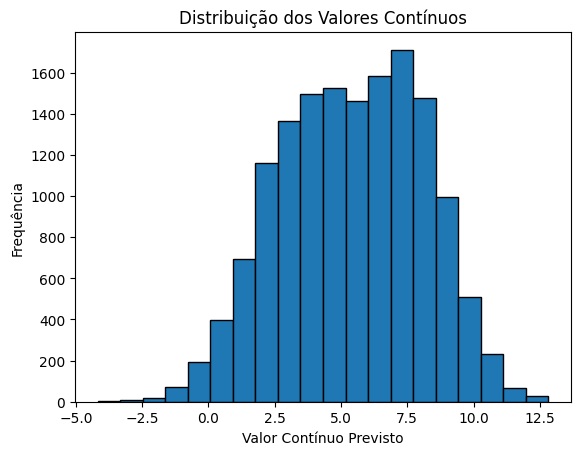

In [28]:
# Visualizar a distribuição dos valores contínuos previstos
plt.hist(y_pred_ridge_cont, bins=20, edgecolor='black')
plt.xlabel('Valor Contínuo Previsto')
plt.ylabel('Frequência')
plt.title('Distribuição dos Valores Contínuos')
plt.show()

In [44]:
# Converter valores contínuos para as classes discretas válidas
def continuous_to_discrete(y_pred):
    y_discrete = []
    for y in y_pred:
        if y <= 1.85:  # Classe 1
            y_discrete.append(1)
        elif y <= 3.3:  # Classe 2
            y_discrete.append(2)
        elif y <= 4.4:  # Classe 3
            y_discrete.append(3)
        elif y <= 5.5:  # Classe 4
            y_discrete.append(4)
        elif y <= 6.7:  # Classe 7
            y_discrete.append(7)
        elif y <= 7.85:  # Classe 8
            y_discrete.append(8)
        elif y <= 9.00:  # Classe 9
            y_discrete.append(9)
        else:  # Classe 10
            y_discrete.append(10)
    return np.array(y_discrete)

# Converter as previsões contínuas
print("Antes: ", np.unique(y_pred_ridge_cont))
y_pred_discrete = continuous_to_discrete(y_pred_ridge_cont)
print("Depois: ", np.unique(y_pred_discrete))

# Avaliar o modelo com valores discretos
print("Relatório de Classificação:\n", classification_report(y_valid, y_pred_discrete))

Antes:  [-4.17957128 -3.59531017 -2.9975604  ... 12.70127414 12.82518356
 12.82555314]
Depois:  [ 1  2  3  4  7  8  9 10]
Relatório de Classificação:
               precision    recall  f1-score   support

           1       0.63      0.31      0.42      3033
           2       0.21      0.32      0.25      1408
           3       0.21      0.27      0.23      1503
           4       0.22      0.27      0.24      1615
           7       0.18      0.29      0.22      1378
           8       0.23      0.31      0.27      1698
           9       0.21      0.28      0.24      1401
          10       0.59      0.25      0.35      2964

    accuracy                           0.28     15000
   macro avg       0.31      0.29      0.28     15000
weighted avg       0.37      0.28      0.30     15000



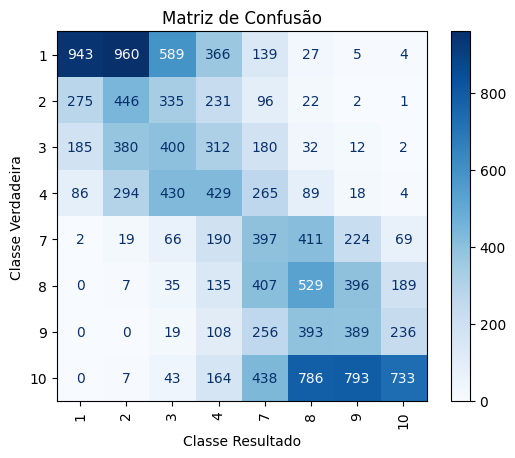

In [36]:
conf_matrix=confusion_matrix(y_valid, y_pred_discrete)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y_test))

# Plot da matriz
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Matriz de Confusão")
plt.xlabel("Classe Resultado")
plt.ylabel("Classe Verdadeira")
plt.show()

# Clustering

In [50]:
num_criticas = 25000

svd = TruncatedSVD(n_components=3, random_state=42)  # Reduz para 50 dimensões
X_train_reduced = svd.fit_transform(X_train_tfidf[:num_criticas, :])

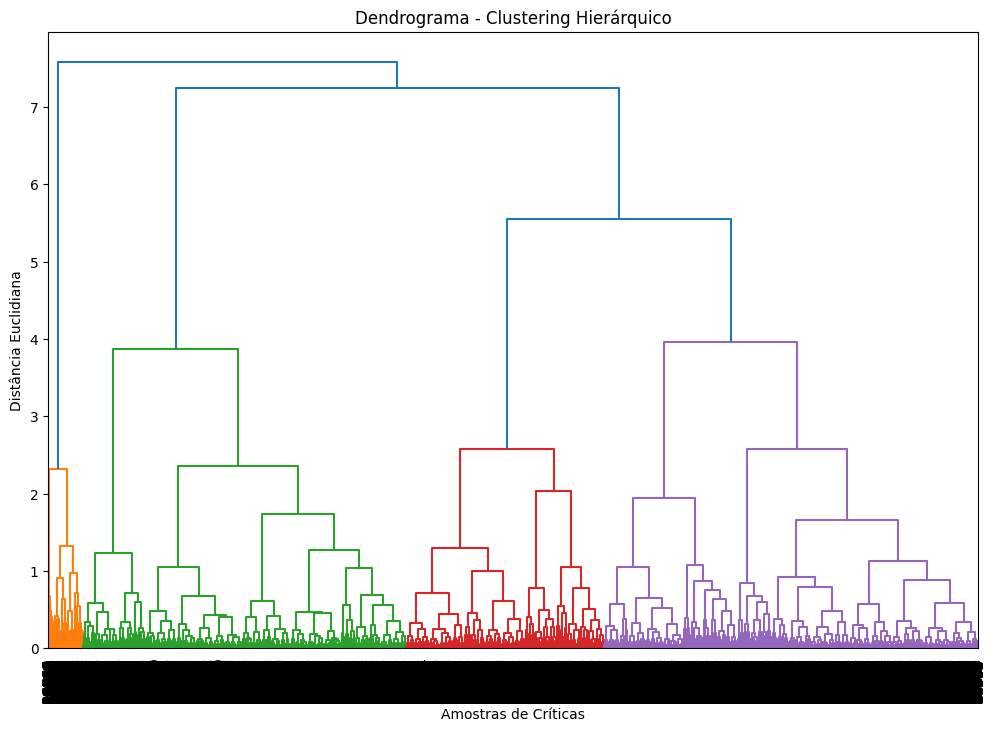

In [51]:
linkage_matrix = linkage(X_train_reduced, method='ward')

# Criar o dendrograma
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=10)
plt.title('Dendrograma - Clustering Hierárquico')
plt.xlabel('Amostras de Críticas')
plt.ylabel('Distância Euclidiana')
#plt.grid(True, linestyle='--', alpha=0.5)
plt.show()